# Geometric Transformations of Images

This notebook demonstrates four fundamental **geometric (spatial) transformations** applied to a synthetic test image:

| # | Transformation | Description |
|---|----------------|-------------|
| 1 | **Scaling** | Resize the image by independent factors along x and y |
| 2 | **Rotation** | Rotate around a centre point by angle θ |
| 3 | **Translation** | Shift the image by (tx, ty) pixels |
| 4 | **Shearing** | Slant the image along the x or y axis |

All four operations are members of the **affine transformation** family and can be expressed as a **3 × 3 matrix** acting on homogeneous coordinates.

---

## Background: Homogeneous Coordinates & the Affine Matrix

A 2-D point $(x, y)$ is written in **homogeneous coordinates** as:

$$\tilde{\mathbf{p}} = \begin{pmatrix} x \\ y \\ 1 \end{pmatrix}$$

Every affine transformation is then a matrix–vector multiplication:

$$\begin{pmatrix} x' \\ y' \\ 1 \end{pmatrix} = \underbrace{\begin{pmatrix} a_{11} & a_{12} & t_x \\ a_{21} & a_{22} & t_y \\ 0 & 0 & 1 \end{pmatrix}}_{\mathbf{M}_{3\times3}} \begin{pmatrix} x \\ y \\ 1 \end{pmatrix}$$

- The **2 × 2 top-left sub-matrix** $A = \begin{pmatrix}a_{11}&a_{12}\\a_{21}&a_{22}\end{pmatrix}$ encodes **linear** effects (scale, rotation, shear).
- The **last column** $(t_x,\, t_y)^\top$ encodes **translation**.
- The **bottom row** $(0,\, 0,\, 1)$ keeps the coordinate homogeneous.

Transformations can be **chained** simply by multiplying their matrices:
$$\mathbf{M}_{\text{combined}} = \mathbf{M}_n \cdots \mathbf{M}_2 \cdot \mathbf{M}_1$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# We use scipy's affine_transform for the actual pixel mapping
from scipy.ndimage import affine_transform

# ── Plotting helper ──────────────────────────────────────────────────────
def show_pair(original, transformed, title, cmap='gray'):
    """Show original and transformed images side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    axes[0].imshow(original,     cmap=cmap, vmin=0, vmax=255, origin='upper')
    axes[0].set_title('Original', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(transformed,  cmap=cmap, vmin=0, vmax=255, origin='upper')
    axes[1].set_title(title,      fontsize=12)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

def apply_affine(img, M, output_shape=None):
    """
    Apply a 3x3 affine matrix M to a 2-D image using inverse mapping.
    scipy.ndimage.affine_transform expects the INVERSE transform
    (output -> input mapping), so we pass M_inv internally.
    """
    if output_shape is None:
        output_shape = img.shape
    M_inv = np.linalg.inv(M)
    A_inv = M_inv[:2, :2]
    b_inv = M_inv[:2,  2]
    return affine_transform(img, A_inv, offset=b_inv,
                            output_shape=output_shape,
                            order=1, mode='constant', cval=0)

print('Setup complete ✓')

Setup complete ✓


---
## Synthetic Test Image

We generate a **256 × 256 grayscale test image** from scratch.  
It contains several geometric features that make every transformation clearly visible:

- A bright rectangle in the centre
- A filled circle
- A diagonal line
- Corner markers
- A text-like "L" shape

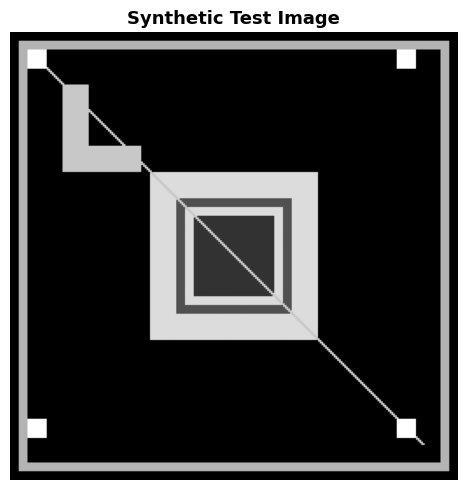

Image shape: (256, 256),  dtype: float32,  range: [0, 255]


In [ ]:
SIZE = 256
img = np.zeros((SIZE, SIZE), dtype=np.float32)

# ── Bright border ────────────────────────────────────────
img[5:10,   5:251] = 180
img[246:251,5:251] = 180
img[5:251,  5:10 ] = 180
img[5:251, 246:251] = 180

# ── Filled rectangle (centre) ────────────────────────────
img[80:176, 80:176] = 220

# ── Hollow inner square ──────────────────────────────────
img[95:161, 95:161] = 80
img[100:156,100:156] = 220
img[105:151,105:151] = 50

# ── Diagonal line (top-left to bottom-right) ─────────────
for i in range(20, 236):
    img[i, i]     = 200
    img[i, i+1]   = 200

# ── Corner markers ───────────────────────────────────────
for r0, c0 in [(15,15),(15,226),(226,15),(226,226)]:
    img[r0-5:r0+6, c0-5:c0+6] = 255

# ── "L" shape (top-left area) ─────────────────────────────
img[30:80, 30:45] = 200     # vertical bar
img[65:80, 30:75] = 200     # horizontal bar

img = np.clip(img, 0, 255)

# ── Display ──────────────────────────────────────────────
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Synthetic Test Image', fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Image shape: {img.shape},  dtype: {img.dtype},  range: [{img.min():.0f}, {img.max():.0f}]')

---
## 1 · Scaling

### Theory

**Scaling** multiplies each coordinate by a factor: $s_x$ along the horizontal axis and $s_y$ along the vertical axis.

$$\mathbf{M}_{\text{scale}} = \begin{pmatrix} s_x & 0 & 0 \\ 0 & s_y & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

| Parameter | Effect |
|-----------|--------|
| $s_x > 1$ | Stretch horizontally |
| $s_x < 1$ | Compress horizontally |
| $s_y > 1$ | Stretch vertically |
| $s_y < 1$ | Compress vertically |
| $s_x = s_y$ | **Isotropic** scaling (preserves shape) |
| $s_x \neq s_y$ | **Anisotropic** scaling (changes aspect ratio) |

The resulting coordinates are:
$$x' = s_x \cdot x, \qquad y' = s_y \cdot y$$

**Determinant:** $\det(\mathbf{M}) = s_x \cdot s_y$ → the area scales by this factor.

Scaling matrix M_scale:
[[0.5  0.   0.  ]
 [0.   0.75 0.  ]
 [0.   0.   1.  ]]

det(M_scale) = 0.3750  (area multiplier = sx*sy = 0.375)


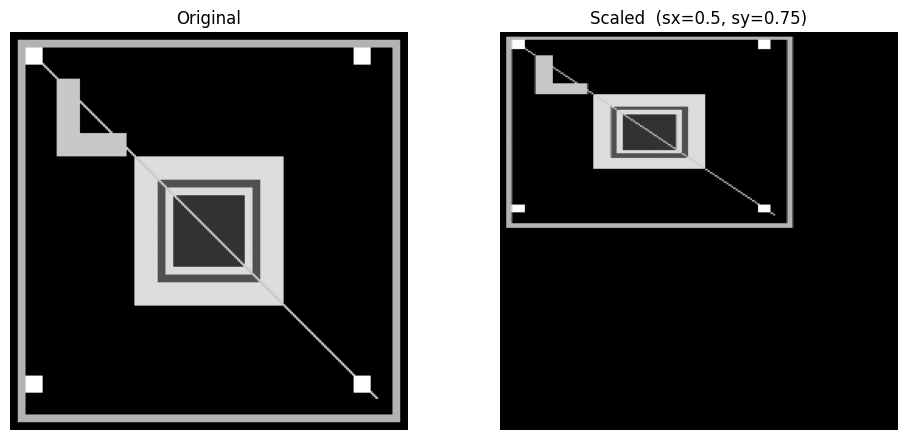

In [ ]:
# ── Scaling parameters ───────────────────────────────────
sx = 1.5   # scale factor along x  (columns)
sy = 0.75  # scale factor along y  (rows)

# ── Affine matrix ────────────────────────────────────────
M_scale = np.array([
    [sx,  0,  0],
    [ 0, sy,  0],
    [ 0,  0,  1]
], dtype=float)

print('Scaling matrix M_scale:')
print(M_scale)
print(f'\ndet(M_scale) = {np.linalg.det(M_scale):.4f}  (area multiplier = sx*sy = {sx*sy})')

# ── Apply transformation ─────────────────────────────────
scaled = apply_affine(img, M_scale)

# ── Display ──────────────────────────────────────────────
show_pair(img, scaled,
          title=f'Scaled  (sx={sx}, sy={sy})')

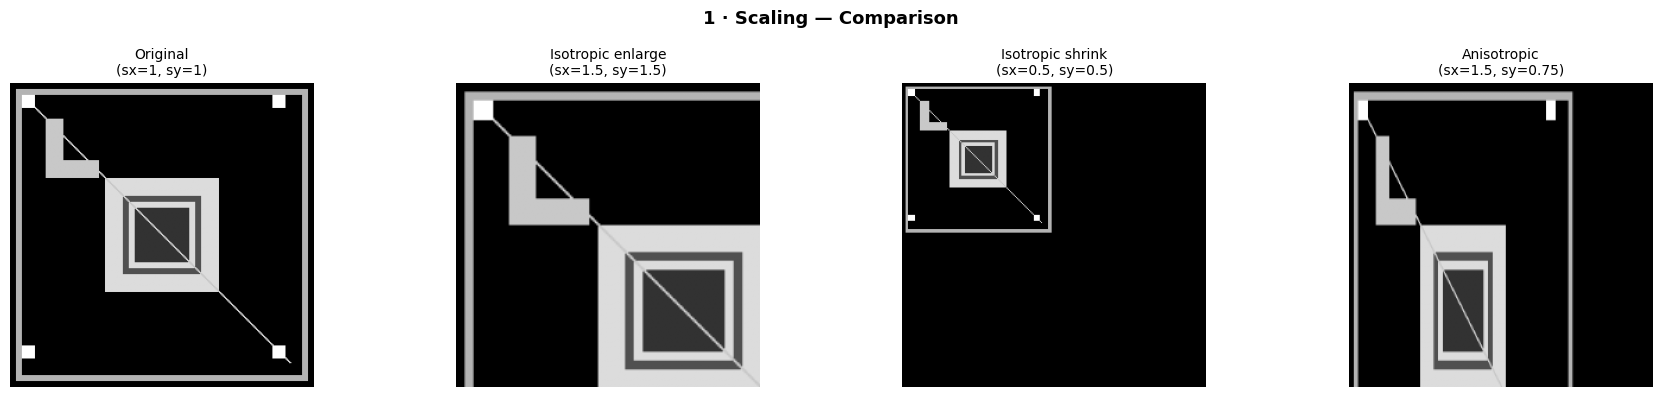

In [ ]:
# ── Side-by-side: three different scale factors ───────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
configs = [
    (1.0, 1.0, 'Original\n(sx=1, sy=1)'),
    (1.5, 1.5, 'Isotropic enlarge\n(sx=1.5, sy=1.5)'),
    (0.5, 0.5, 'Isotropic shrink\n(sx=0.5, sy=0.5)'),
    (1.5, 0.75,'Anisotropic\n(sx=1.5, sy=0.75)'),
]
for ax, (s_x, s_y, title) in zip(axes, configs):
    M = np.diag([s_x, s_y, 1.0])
    out = apply_affine(img, M)
    ax.imshow(out, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.suptitle('1 · Scaling — Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2 · Rotation

### Theory

**Rotation** by angle $\theta$ (counter-clockwise, in radians) about the **origin**:

$$\mathbf{M}_{\text{rot}} = \begin{pmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

To rotate about an **arbitrary centre** $(c_x, c_y)$, we must:
1. **Translate** the centre to the origin: $\mathbf{M}_{T_1}$ (shift by $-c_x, -c_y$)
2. **Rotate**: $\mathbf{M}_{\text{rot}}$
3. **Translate back**: $\mathbf{M}_{T_2}$ (shift by $+c_x, +c_y$)

$$\mathbf{M}_{\text{rot@centre}} = \mathbf{M}_{T_2} \cdot \mathbf{M}_{\text{rot}} \cdot \mathbf{M}_{T_1}$$

Expanding this product:

$$\mathbf{M}_{\text{rot@centre}} = \begin{pmatrix} \cos\theta & -\sin\theta & c_x(1-\cos\theta)+c_y\sin\theta \\ \sin\theta & \cos\theta & c_y(1-\cos\theta)-c_x\sin\theta \\ 0 & 0 & 1 \end{pmatrix}$$

**Key property:** $\det(\mathbf{M}_{\text{rot}}) = \cos^2\theta + \sin^2\theta = 1$ → rotation **preserves area and shape**.

Rotation matrix M_rot (θ = 45°):
[[  0.7071  -0.7071 128.    ]
 [  0.7071   0.7071 -53.0193]
 [  0.       0.       1.    ]]

det(M_rot) = 1.000000  (should be exactly 1.0)


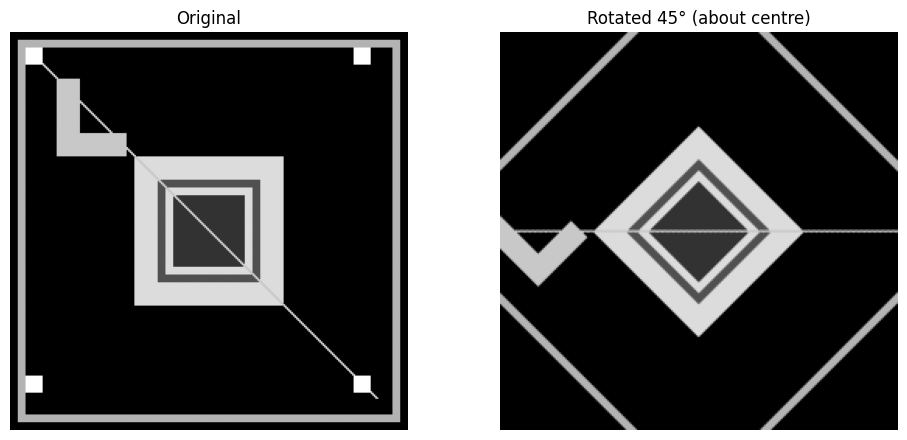

In [ ]:
def rotation_matrix(theta_deg, cx=None, cy=None, size=SIZE):
    """Build a 3x3 rotation matrix for angle theta_deg around (cx, cy)."""
    if cx is None: cx = size / 2
    if cy is None: cy = size / 2
    theta = np.radians(theta_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)

    # Pure rotation about origin
    M_rot = np.array([
        [ cos_t, -sin_t, 0],
        [ sin_t,  cos_t, 0],
        [     0,      0, 1]
    ], dtype=float)

    # Translate to/from the rotation centre
    M_t1 = np.array([[1,0,-cx],[0,1,-cy],[0,0,1]], dtype=float)
    M_t2 = np.array([[1,0, cx],[0,1, cy],[0,0,1]], dtype=float)

    return M_t2 @ M_rot @ M_t1


# ── Rotation by 45° about image centre ───────────────────
theta = 45
M_rot = rotation_matrix(theta)

print(f'Rotation matrix M_rot (θ = {theta}°):')
print(np.round(M_rot, 4))
print(f'\ndet(M_rot) = {np.linalg.det(M_rot):.6f}  (should be exactly 1.0)')

rotated = apply_affine(img, M_rot)
show_pair(img, rotated, title=f'Rotated {theta}° (about centre)')

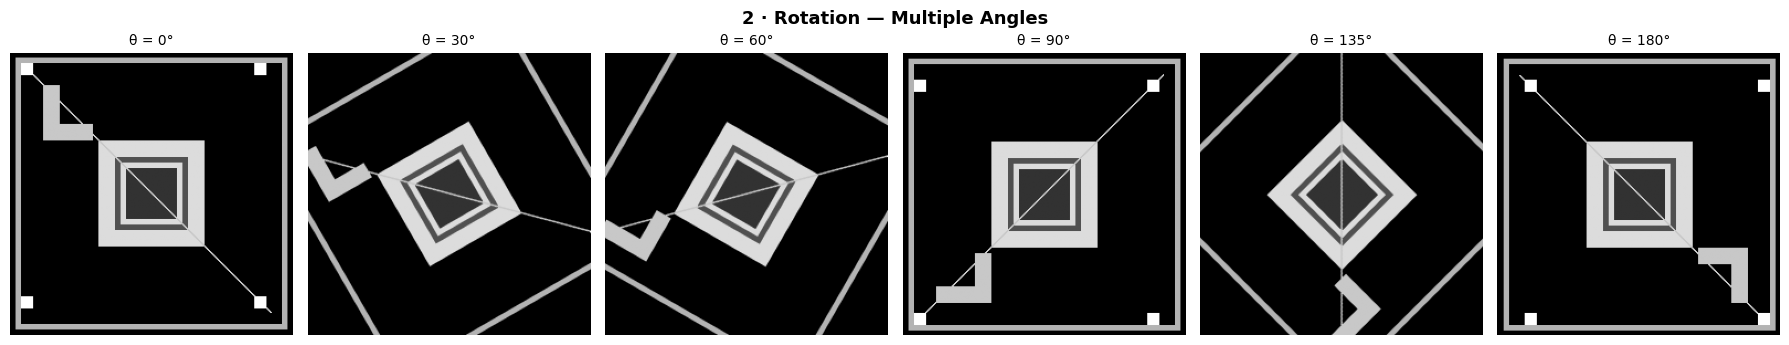

In [ ]:
# ── Multiple rotation angles ──────────────────────────────
angles = [0, 30, 60, 90, 135, 180]
fig, axes = plt.subplots(1, len(angles), figsize=(18, 3.5))

for ax, angle in zip(axes, angles):
    M = rotation_matrix(angle)
    out = apply_affine(img, M)
    ax.imshow(out, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'θ = {angle}°', fontsize=10)
    ax.axis('off')

fig.suptitle('2 · Rotation — Multiple Angles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3 · Translation

### Theory

**Translation** shifts every point by a fixed vector $(t_x, t_y)$:

$$x' = x + t_x, \qquad y' = y + t_y$$

In homogeneous coordinates this is:

$$\mathbf{M}_{\text{trans}} = \begin{pmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \\ 0 & 0 & 1 \end{pmatrix}$$

**Key properties:**
- The $2 \times 2$ sub-matrix is the **identity** — no shape distortion occurs.
- $\det(\mathbf{M}) = 1$ → area is **preserved**.
- Translation **cannot** be expressed as a $2 \times 2$ matrix, which is exactly why homogeneous coordinates are useful.

| Parameter | Effect |
|-----------|--------|
| $t_x > 0$ | Shift right |
| $t_x < 0$ | Shift left |
| $t_y > 0$ | Shift down |
| $t_y < 0$ | Shift up |

Translation matrix M_trans:
[[  1.   0.  60.]
 [  0.   1. -40.]
 [  0.   0.   1.]]

det(M_trans) = 1.0000  (always 1 for pure translation)


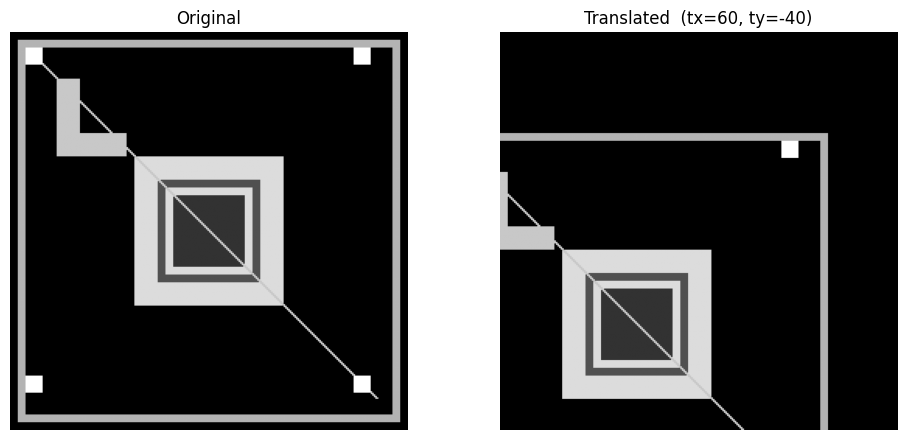

In [ ]:
# ── Translation parameters ───────────────────────────────
tx = 60    # shift right by 60 pixels
ty = -40   # shift up   by 40 pixels

# ── Affine matrix ────────────────────────────────────────
M_trans = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0,  1]
], dtype=float)

print('Translation matrix M_trans:')
print(M_trans)
print(f'\ndet(M_trans) = {np.linalg.det(M_trans):.4f}  (always 1 for pure translation)')

# ── Apply transformation ─────────────────────────────────
translated = apply_affine(img, M_trans)

show_pair(img, translated, title=f'Translated  (tx={tx}, ty={ty})')

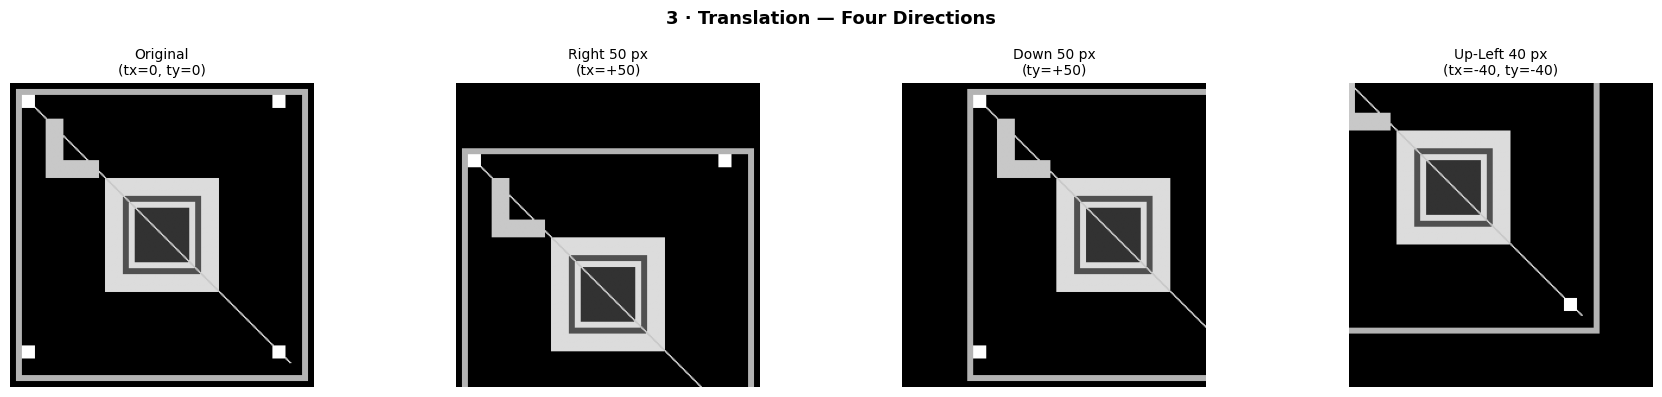

In [ ]:
# ── Four cardinal translation directions ─────────────────
shifts = [
    ( 0,   0,  'Original\n(tx=0, ty=0)'),
    ( 50,  0,  'Right 50 px\n(tx=+50)'),
    (  0, 50,  'Down 50 px\n(ty=+50)'),
    (-40,-40,  'Up-Left 40 px\n(tx=-40, ty=-40)'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (t_x, t_y, title) in zip(axes, shifts):
    M = np.array([[1,0,t_x],[0,1,t_y],[0,0,1]], dtype=float)
    out = apply_affine(img, M)
    ax.imshow(out, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.suptitle('3 · Translation — Four Directions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4 · Shearing

### Theory

**Shearing** slants the image along one axis proportionally to the other axis coordinate.

#### X-Shear (horizontal shear)
Each column is shifted vertically by an amount proportional to its x-coordinate:

$$x' = x + m_x \cdot y, \qquad y' = y$$

$$\mathbf{M}_{\text{shear-x}} = \begin{pmatrix} 1 & m_x & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

#### Y-Shear (vertical shear)
Each row is shifted horizontally by an amount proportional to its y-coordinate:

$$x' = x, \qquad y' = m_y \cdot x + y$$

$$\mathbf{M}_{\text{shear-y}} = \begin{pmatrix} 1 & 0 & 0 \\ m_y & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

#### Combined Shear

$$\mathbf{M}_{\text{shear-xy}} = \begin{pmatrix} 1 & m_x & 0 \\ m_y & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

**Key properties:**
- $\det(\mathbf{M}) = 1 - m_x \cdot m_y$ → shear **preserves area** when $m_x \cdot m_y = 0$ (pure x or y shear).
- Shear turns **rectangles into parallelograms** but preserves parallel lines.
- It is used in **font rendering**, **2-D animation**, and **rotation decomposition** (Paeth's 3-shear rotation algorithm).

X-Shear matrix M_shear_x:
[[1.  0.4 0. ]
 [0.  1.  0. ]
 [0.  0.  1. ]]
det(M_shear_x) = 1.0000  (= 1 for pure x-shear)


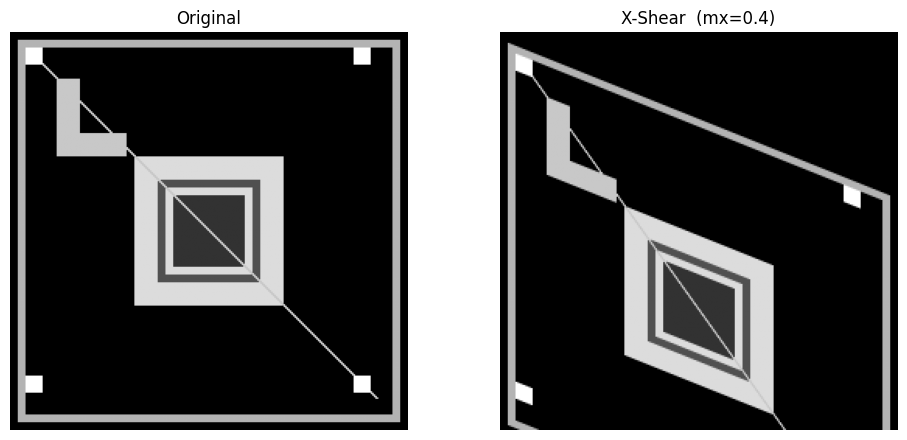

In [ ]:
# ── X-Shear ───────────────────────────────────────────────
mx = 0.4   # horizontal shear factor

M_shear_x = np.array([
    [1, mx, 0],
    [0,  1, 0],
    [0,  0, 1]
], dtype=float)

print('X-Shear matrix M_shear_x:')
print(M_shear_x)
print(f'det(M_shear_x) = {np.linalg.det(M_shear_x):.4f}  (= 1 for pure x-shear)')

sheared_x = apply_affine(img, M_shear_x)
show_pair(img, sheared_x, title=f'X-Shear  (mx={mx})')

Y-Shear matrix M_shear_y:
[[1.  0.  0. ]
 [0.4 1.  0. ]
 [0.  0.  1. ]]
det(M_shear_y) = 1.0000  (= 1 for pure y-shear)


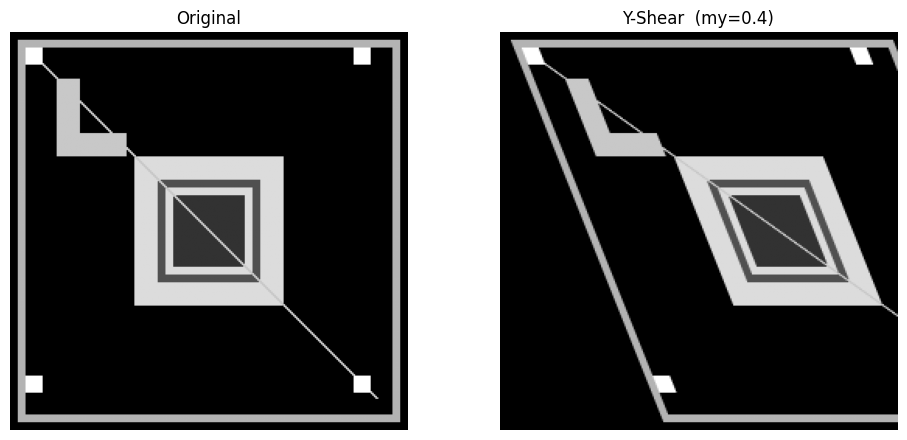

In [ ]:
# ── Y-Shear ───────────────────────────────────────────────
my = 0.4   # vertical shear factor

M_shear_y = np.array([
    [ 1, 0, 0],
    [my, 1, 0],
    [ 0, 0, 1]
], dtype=float)

print('Y-Shear matrix M_shear_y:')
print(M_shear_y)
print(f'det(M_shear_y) = {np.linalg.det(M_shear_y):.4f}  (= 1 for pure y-shear)')

sheared_y = apply_affine(img, M_shear_y)
show_pair(img, sheared_y, title=f'Y-Shear  (my={my})')

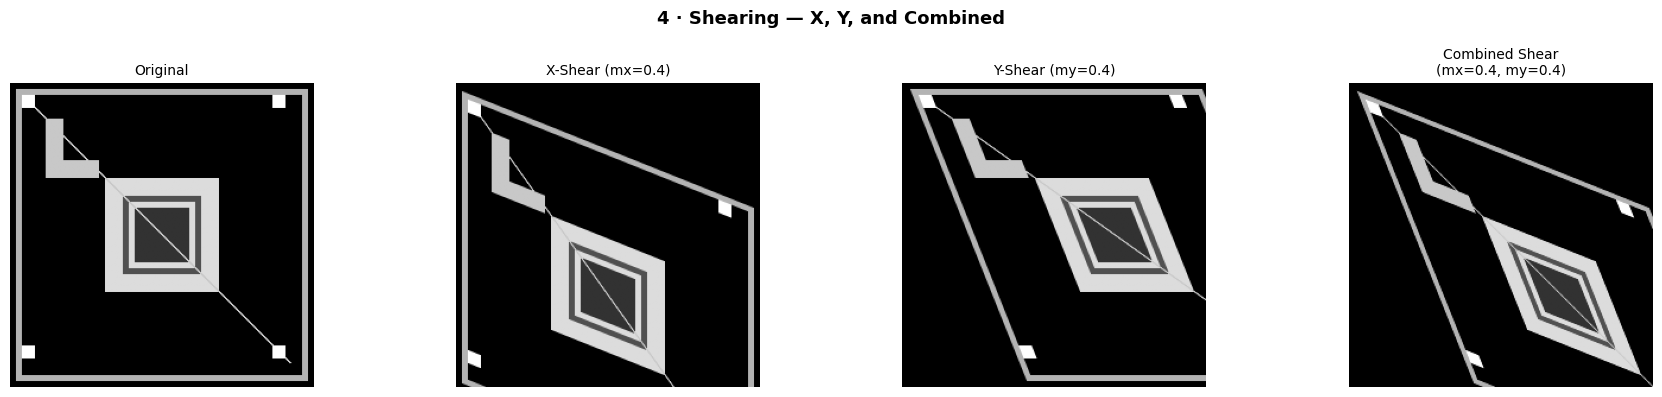

In [ ]:
# ── Comparison: no shear / x-shear / y-shear / combined ──
M_shear_xy = np.array([[1, mx, 0],[my, 1, 0],[0, 0, 1]], dtype=float)

configs = [
    (np.eye(3),    f'Original'),
    (M_shear_x,    f'X-Shear (mx={mx})'),
    (M_shear_y,    f'Y-Shear (my={my})'),
    (M_shear_xy,   f'Combined Shear\n(mx={mx}, my={my})'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (M, title) in zip(axes, configs):
    out = apply_affine(img, M)
    ax.imshow(out, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.suptitle('4 · Shearing — X, Y, and Combined', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5 · Combined Transformation (Composition)

Because all transformations are expressed as **matrix multiplications**, they can be **chained** into a single affine matrix.

**Order matters** — matrix multiplication is generally **not commutative**: $\mathbf{M}_A \cdot \mathbf{M}_B \neq \mathbf{M}_B \cdot \mathbf{M}_A$.

The combined matrix $\mathbf{M}_{\text{comb}}$ below applies:
1. Scale $\times 0.8$ isotropically
2. Rotate $30°$ about the image centre
3. Translate $(+30, +20)$ pixels
4. X-shear by $0.2$

Combined matrix  M = M_shear @ M_trans @ M_rot @ M_scale:
[[  0.7728  -0.2614 105.7785]
 [  0.4      0.6928 -26.8513]
 [  0.       0.       1.    ]]

det(M_combined) = 0.6400


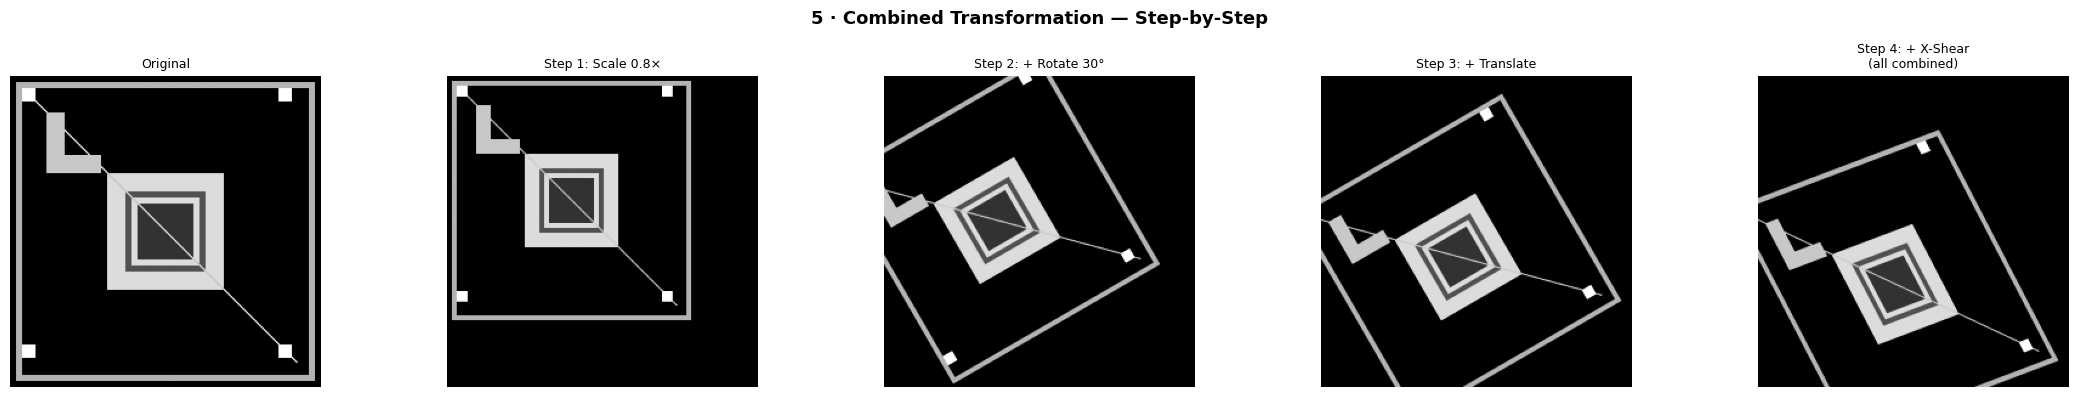

In [ ]:
# ── Build individual matrices ─────────────────────────────
M_s  = np.diag([0.8, 0.8, 1.0])                          # scale
M_r  =  (30)                                 # rotate 30°
M_t  = np.array([[1,0,30],[0,1,20],[0,0,1]], dtype=float)  # translate
M_sh = np.array([[1,0.2,0],[0,1,0],[0,0,1]], dtype=float)  # x-shear

# ── Chain (right-to-left: scale first, then rotate, then translate, then shear)
M_combined = M_sh @ M_t @ M_r @ M_s

print('Combined matrix  M = M_shear @ M_trans @ M_rot @ M_scale:')
print(np.round(M_combined, 4))
print(f'\ndet(M_combined) = {np.linalg.det(M_combined):.4f}')

combined = apply_affine(img, M_combined)

# ── Show all five panels ──────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
panels = [
    (img,                       'Original'),
    (apply_affine(img, M_s),    'Step 1: Scale 0.8×'),
    (apply_affine(img, M_r@M_s),'Step 2: + Rotate 30°'),
    (apply_affine(img, M_t@M_r@M_s), 'Step 3: + Translate'),
    (combined,                  'Step 4: + X-Shear\n(all combined)'),
]
for ax, (out, title) in zip(axes, panels):
    ax.imshow(out, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

fig.suptitle('5 · Combined Transformation — Step-by-Step', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6 · Summary: All Affine Matrices at a Glance

In [ ]:
import sympy as sp

sx, sy, theta, tx, ty, mx, my, cx, cy = sp.symbols(
    'sx sy theta tx ty mx my cx cy', real=True)

# ── Symbolic matrices ────────────────────────────────────
M_scale_sym = sp.Matrix([
    [sx, 0, 0],
    [0, sy, 0],
    [0,  0, 1]
])

M_rot_sym = sp.Matrix([
    [sp.cos(theta), -sp.sin(theta), 0],
    [sp.sin(theta),  sp.cos(theta), 0],
    [0,              0,             1]
])

M_trans_sym = sp.Matrix([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0,  1]
])

M_shear_sym = sp.Matrix([
    [1, mx, 0],
    [my, 1, 0],
    [0,  0, 1]
])

print('=== SCALING ===')
sp.pprint(M_scale_sym)
print(f'  determinant = {sp.det(M_scale_sym)}')
print()

print('=== ROTATION (about origin) ===')
sp.pprint(M_rot_sym)
print(f'  determinant = {sp.trigsimp(sp.det(M_rot_sym))}')
print()

print('=== TRANSLATION ===')
sp.pprint(M_trans_sym)
print(f'  determinant = {sp.det(M_trans_sym)}')
print()

print('=== SHEARING (combined x+y) ===')
sp.pprint(M_shear_sym)
print(f'  determinant = {sp.det(M_shear_sym)}')

=== SCALING ===
⎡sx  0   0⎤
⎢         ⎥
⎢0   sy  0⎥
⎢         ⎥
⎣0   0   1⎦
  determinant = sx*sy

=== ROTATION (about origin) ===
⎡cos(θ)  -sin(θ)  0⎤
⎢                  ⎥
⎢sin(θ)  cos(θ)   0⎥
⎢                  ⎥
⎣  0        0     1⎦
  determinant = 1

=== TRANSLATION ===
⎡1  0  tx⎤
⎢        ⎥
⎢0  1  ty⎥
⎢        ⎥
⎣0  0  1 ⎦
  determinant = 1

=== SHEARING (combined x+y) ===
⎡1   mx  0⎤
⎢         ⎥
⎢my  1   0⎥
⎢         ⎥
⎣0   0   1⎦
  determinant = -mx*my + 1


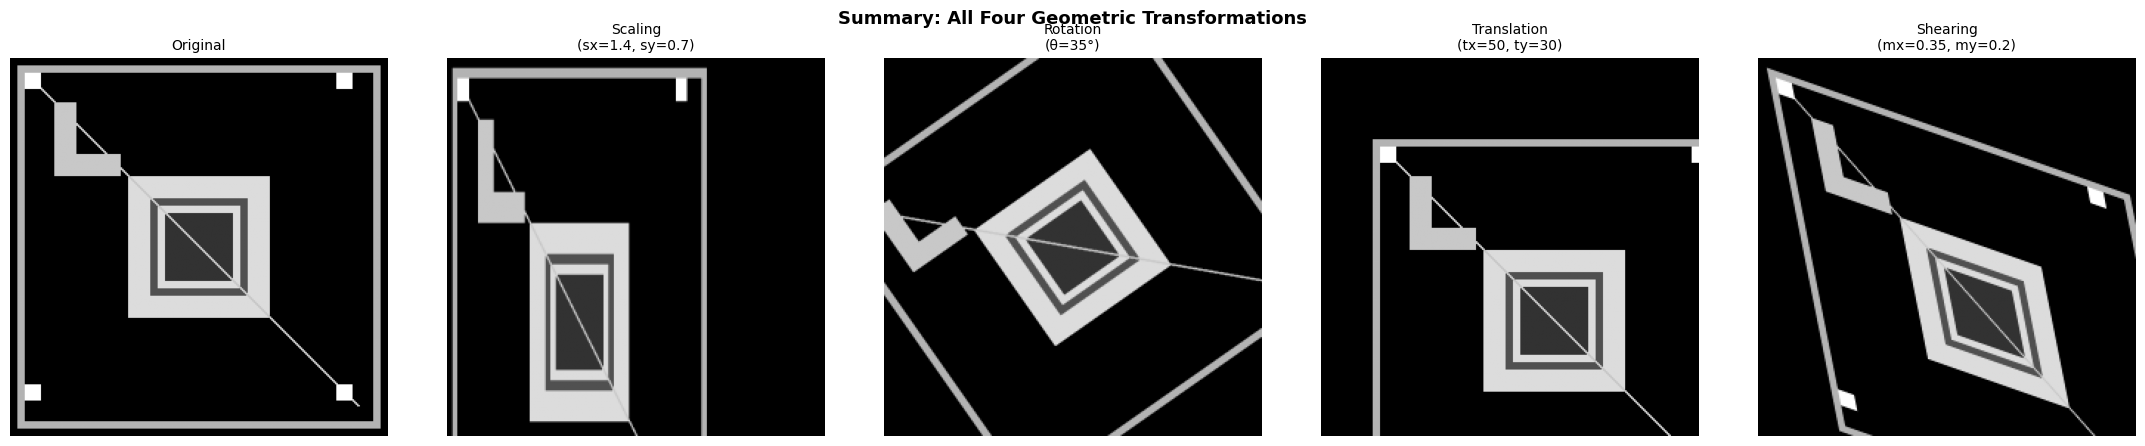

In [ ]:
# ── Visual summary: all four transforms in one figure ─────
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

results = [
    (img,                                         'Original'),
    (apply_affine(img, np.diag([1.4, 0.7, 1.0])), 'Scaling\n(sx=1.4, sy=0.7)'),
    (apply_affine(img, rotation_matrix(35)),       'Rotation\n(θ=35°)'),
    (apply_affine(img, np.array([[1,0,50],[0,1,30],[0,0,1]],dtype=float)),
                                                   'Translation\n(tx=50, ty=30)'),
    (apply_affine(img, np.array([[1,0.35,0],[0.2,1,0],[0,0,1]],dtype=float)),
                                                   'Shearing\n(mx=0.35, my=0.2)'),
]

for ax, (out, title) in zip(axes, results):
    ax.imshow(out, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.suptitle('Summary: All Four Geometric Transformations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary Table

| Transformation | Affine Matrix $\mathbf{M}$ | $\det(\mathbf{M})$ | Preserves |
|---|---|---|---|
| **Scaling** | $\text{diag}(s_x,\, s_y,\, 1)$ | $s_x \cdot s_y$ | Parallel lines; angles only if $s_x = s_y$ |
| **Rotation** | $\begin{pmatrix}\cos\theta & -\sin\theta \\ \sin\theta & \cos\theta\end{pmatrix}$ block | $1$ | Distances, angles, area |
| **Translation** | Identity block + $(t_x, t_y)^\top$ | $1$ | Distances, angles, area, shape |
| **Shearing** | $\begin{pmatrix}1 & m_x \\ m_y & 1\end{pmatrix}$ block | $1 - m_x m_y$ | Parallel lines; area if $m_x=0$ or $m_y=0$ |

> **Key insight:** Any composition of the above four operations is still an **affine transformation**, representable as a single $3 \times 3$ matrix. Affine maps always preserve **straight lines** and **parallelism**.